In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

In [3]:
df = pd.read_csv('pokemon_movepool_data.csv')
print(df.shape)
print(df.columns.tolist())
df.head(5)

(847, 26)
['id', 'name', 'type1', 'type2', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'is_legendary', 'is_mythical', 'dex_number', 'tier', 'abilities', 'types', 'is_fully_evolved', 'has_recovery', 'has_setup', 'has_priority', 'has_pivot', 'has_hazards', 'has_status', 'total_moves', 'coverage_types', 'avg_power']


,id,name,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,...,is_fully_evolved,has_recovery,has_setup,has_priority,has_pivot,has_hazards,has_status,total_moves,coverage_types,avg_power
0,1,bulbasaur,grass,poison,45,49,49,65,65,45,...,False,True,True,False,False,False,True,47,4,72.80
1,2,ivysaur,grass,poison,60,62,63,80,80,60,...,False,True,True,False,False,False,True,48,4,72.80
2,3,venusaur,grass,poison,80,82,83,100,100,80,...,True,True,True,False,False,False,True,59,5,81.32
3,4,charmander,fire,NaN,39,52,43,60,50,65,...,False,True,True,False,False,False,False,58,10,77.86
4,5,charmeleon,fire,NaN,58,64,58,80,65,80,...,False,True,True,False,False,False,False,58,10,77.86


In [5]:
df['type2'] = df['type2'].fillna('None')

def classify(row):
    if row['is_mythical']:
        return 'Mythical'
    elif row['is_legendary']:
        return 'Legendary'
    else:
        return 'Regular'

df['classification'] = df.apply(classify, axis=1)

df['base_stat_total'] = df['hp'] + df['attack'] + df['defense'] + df['sp_attack'] + df['sp_defense'] + df['speed']
df['power_score'] = (
    df['attack'] * 0.25 +
    df['sp_attack'] * 0.25 +
    df['speed'] * 0.25 +
    df['defense'] * 0.125 +
    df['sp_defense'] * 0.125 +
    df['hp'] * 0.10
)

print(df.shape)
print(df['classification'].value_counts())

(847, 29)
classification
Regular      722
Legendary     84
Mythical      41
Name: count, dtype: int64


In [7]:
type_colors = {
    'fire': '#F08030',
    'water': '#6890F0',
    'grass': '#78C850',
    'electric': '#F8D030',
    'psychic': '#F85888',
    'ice': '#98D8D8',
    'dragon': '#7038F8',
    'dark': '#705848',
    'fairy': '#EE99AC',
    'fighting': '#C03028',
    'flying': '#A890F0',
    'poison': '#A040A0',
    'ground': '#E0C068',
    'rock': '#B8A038',
    'bug': '#A8B820',
    'ghost': '#705898',
    'steel': '#B8B8D0',
    'normal': '#A8A878',
}

tier_colors = {
    'AG': '#FF0000',
    'Uber': '#FF6600',
    'OU': '#FFD700',
    'UUBL': '#90EE90',
    'UU': '#00CC00',
    'RUBL': '#00FFFF',
    'RU': '#0099FF',
    'NUBL': '#9370DB',
    'NU': '#800080',
    'PUBL': '#FF69B4',
    'PU': '#FF1493',
    'ZUBL': '#A0522D',
    'ZU': '#8B4513',
    'NFE': '#808080',
    'LC': '#C0C0C0',
    'Untiered': '#FFFFFF'
}

stat_colors = {
    'hp': '#FF5959',
    'attack': '#F5AC78',
    'defense': '#FAE078',
    'sp_attack': '#9DB7F5',
    'sp_defense': '#A7DB8D',
    'speed': '#FA92B2'
}

print("Colors defined")

Colors defined


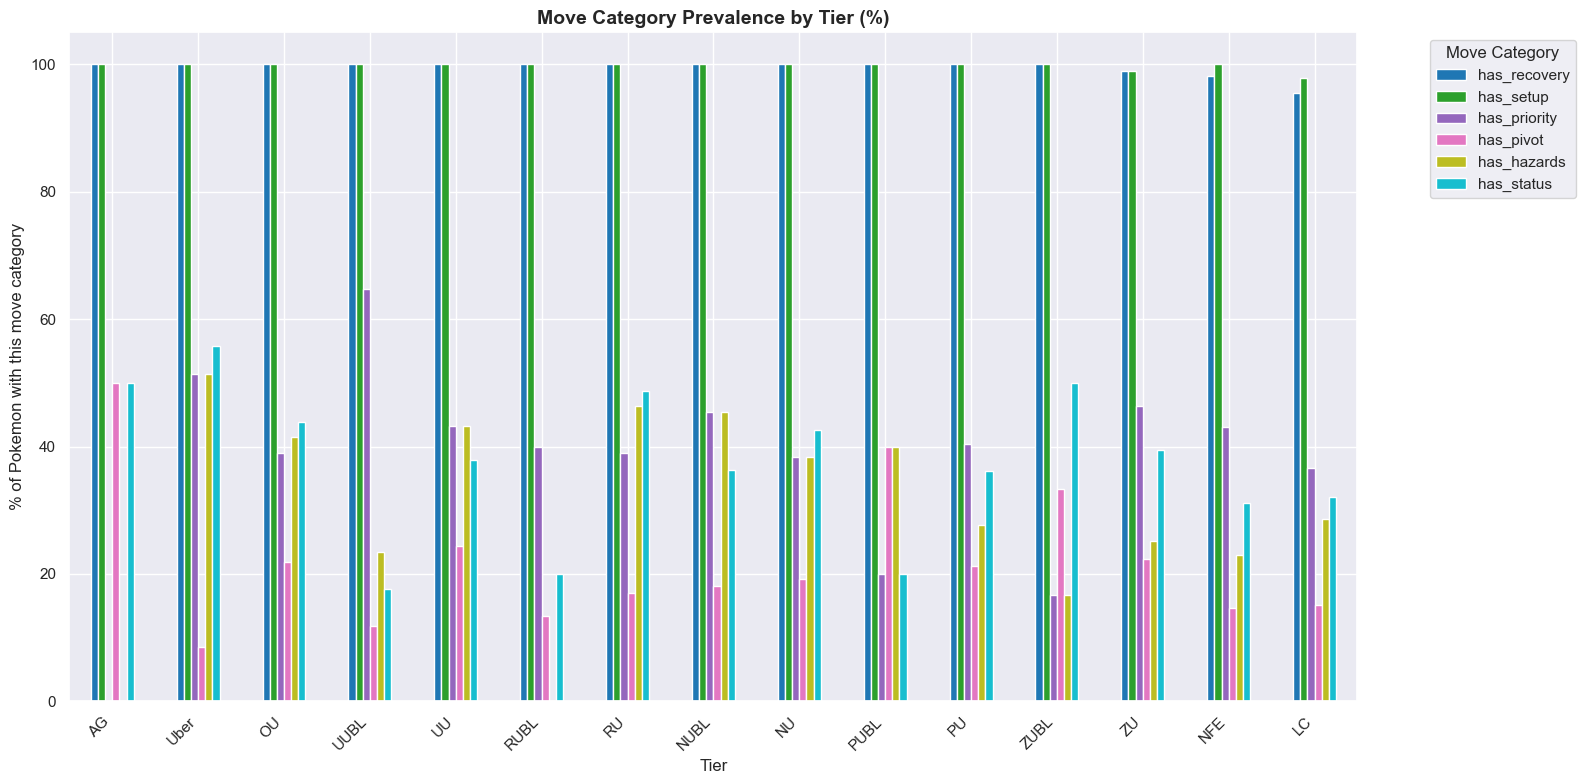

In [9]:
tier_order = ['AG', 'Uber', 'OU', 'UUBL', 'UU', 'RUBL', 'RU', 
              'NUBL', 'NU', 'PUBL', 'PU', 'ZUBL', 'ZU', 'NFE', 'LC']

features = ['has_recovery', 'has_setup', 'has_priority', 
            'has_pivot', 'has_hazards', 'has_status']

df_filtered = df[df['tier'].isin(tier_order)]

tier_features = df_filtered.groupby('tier')[features].mean().reindex(tier_order) * 100

tier_features.plot(
    kind='bar',
    figsize=(16, 8),
    colormap='tab10'
)
plt.title('Move Category Prevalence by Tier (%)', fontsize=14, fontweight='bold')
plt.xlabel('Tier')
plt.ylabel('% of Pokemon with this move category')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Move Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

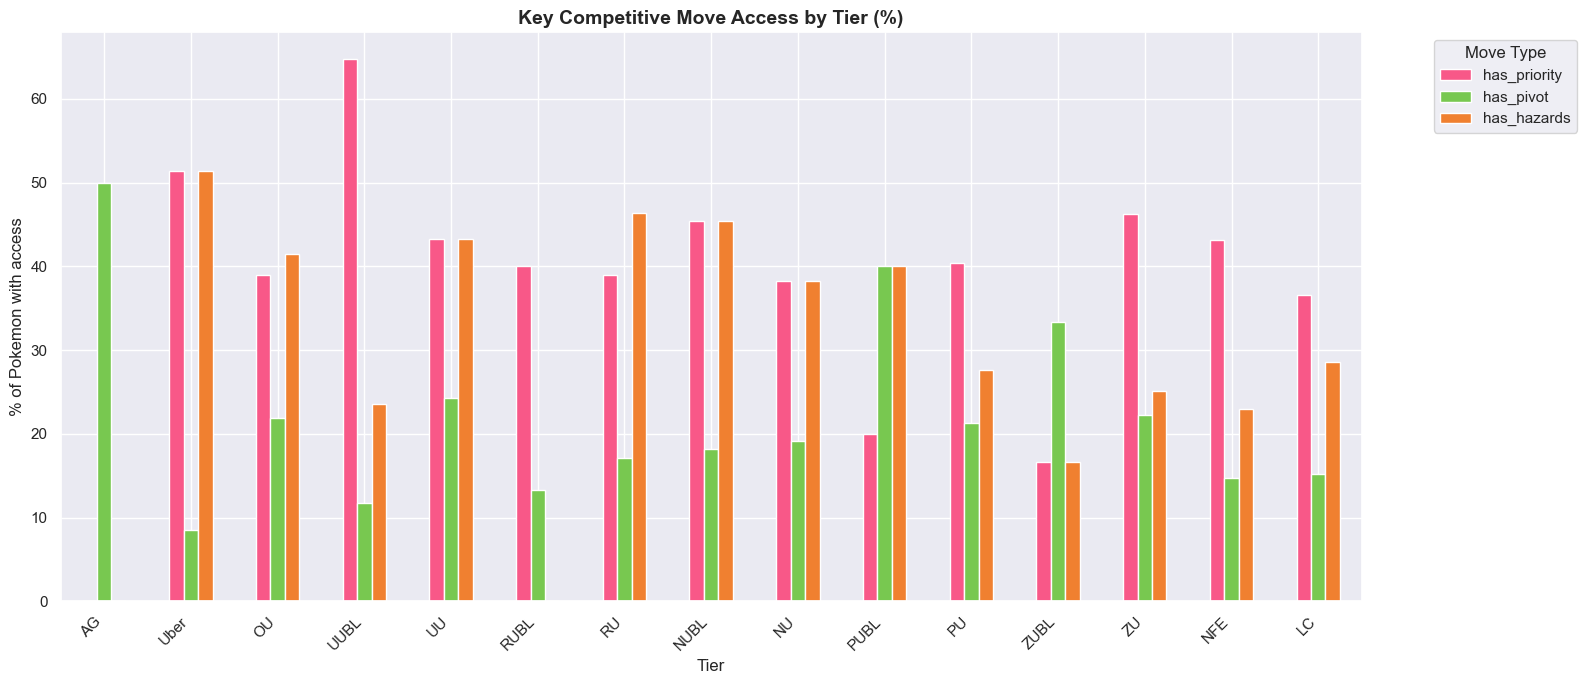

In [11]:
key_features = ['has_priority', 'has_pivot', 'has_hazards']

tier_key = df_filtered.groupby('tier')[key_features].mean().reindex(tier_order) * 100

tier_key.plot(
    kind='bar',
    figsize=(16, 7),
    color=['#F85888', '#78C850', '#F08030']
)
plt.title('Key Competitive Move Access by Tier (%)', fontsize=14, fontweight='bold')
plt.xlabel('Tier')
plt.ylabel('% of Pokemon with access')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Move Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

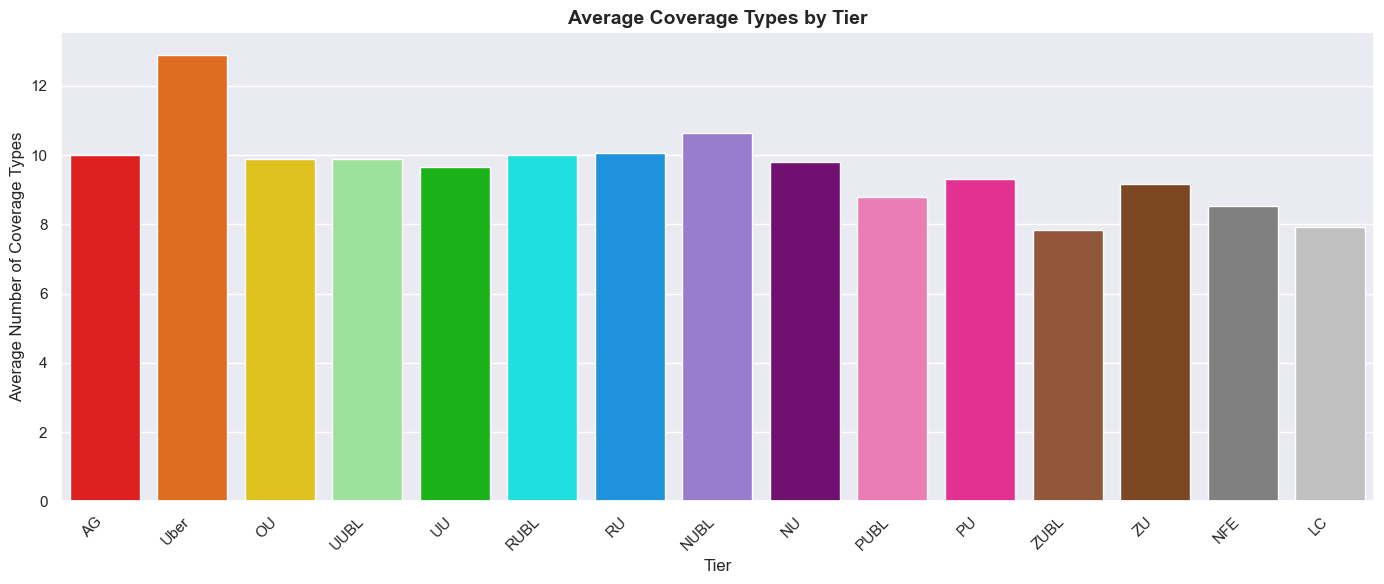

In [13]:
tier_coverage = df_filtered.groupby('tier')['coverage_types'].mean().reindex(tier_order)

plt.figure(figsize=(14, 6))
sns.barplot(
    x=tier_coverage.index,
    y=tier_coverage.values,
    hue=tier_coverage.index,
    legend=False,
    palette=tier_colors
)
plt.title('Average Coverage Types by Tier', fontsize=14, fontweight='bold')
plt.xlabel('Tier')
plt.ylabel('Average Number of Coverage Types')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

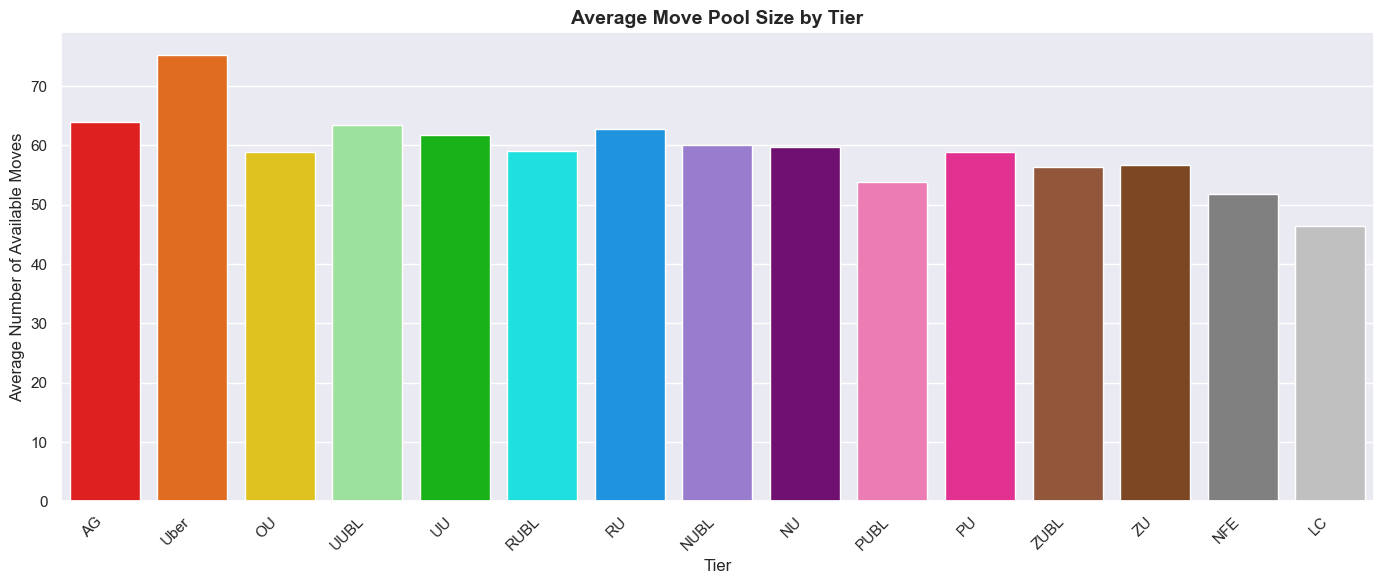

In [15]:
tier_moves = df_filtered.groupby('tier')['total_moves'].mean().reindex(tier_order)

plt.figure(figsize=(14, 6))
sns.barplot(
    x=tier_moves.index,
    y=tier_moves.values,
    hue=tier_moves.index,
    legend=False,
    palette=tier_colors
)
plt.title('Average Move Pool Size by Tier', fontsize=14, fontweight='bold')
plt.xlabel('Tier')
plt.ylabel('Average Number of Available Moves')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

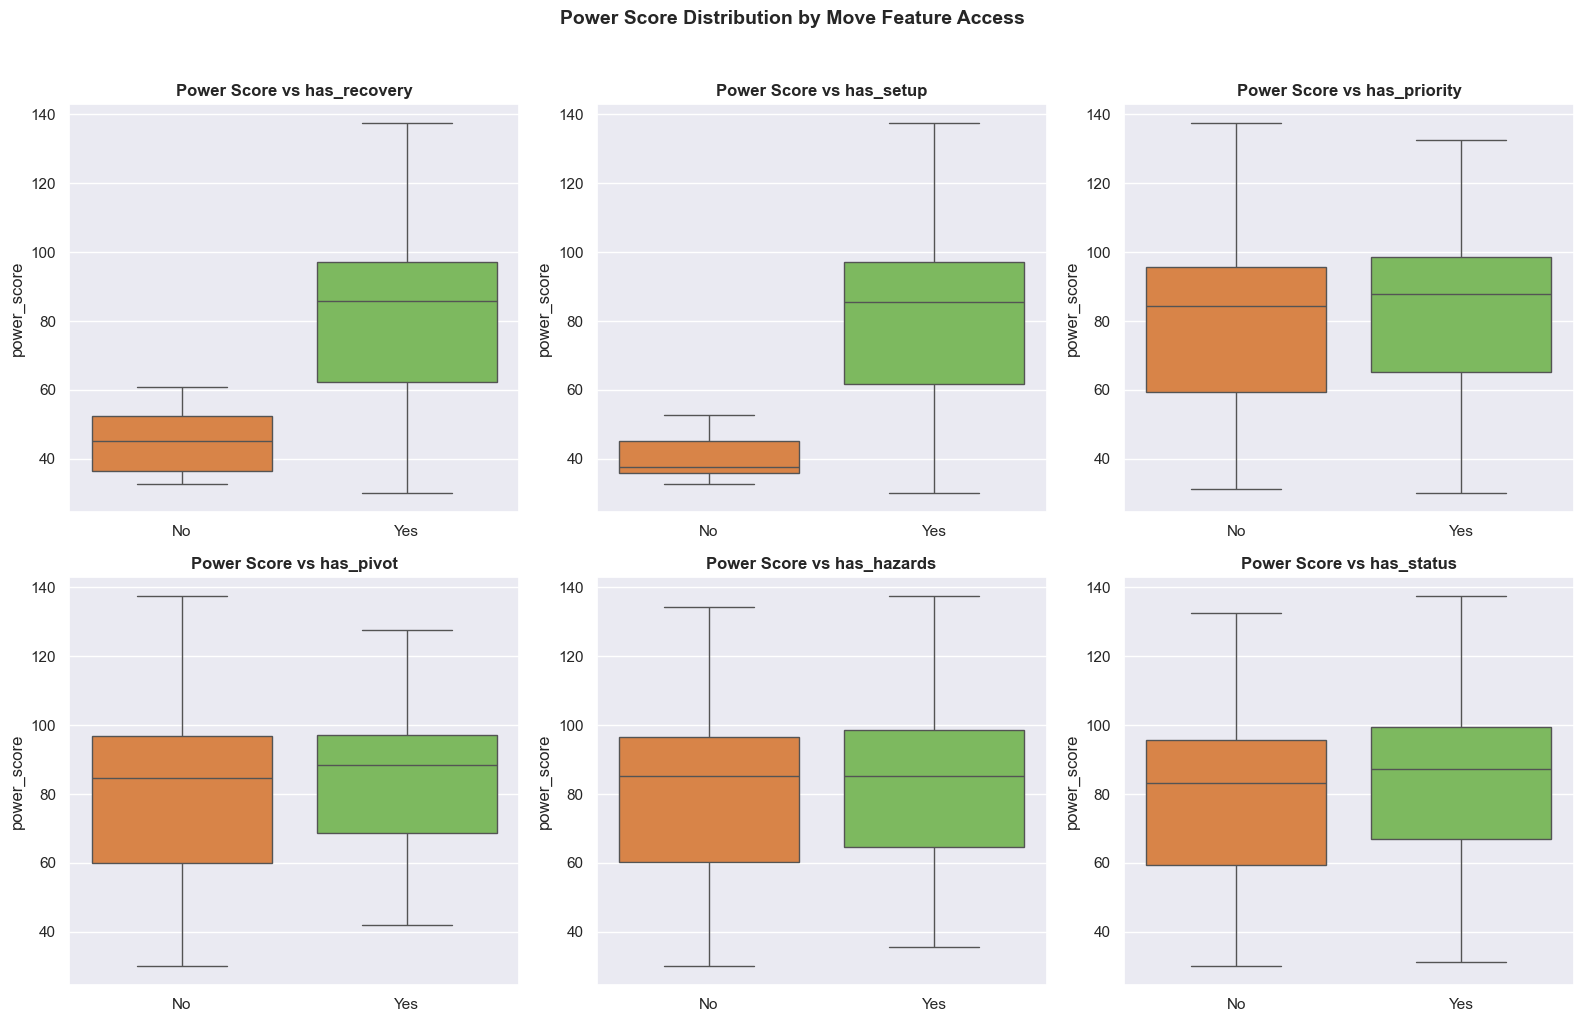

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = ['has_recovery', 'has_setup', 'has_priority', 
            'has_pivot', 'has_hazards', 'has_status']

for i, feature in enumerate(features):
    sns.boxplot(
        data=df_filtered,
        x=feature,
        y='power_score',
        hue=feature,
        palette={True: '#78C850', False: '#F08030'},
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'Power Score vs {feature}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No', 'Yes'])

plt.suptitle('Power Score Distribution by Move Feature Access', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()